### Set up

In [1]:
import torchvision
import torchvision.transforms.v2 as T
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import torchmetrics
import torch.nn.functional as F

In [2]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
device

'cuda'

### Load dataset

In [3]:
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

In [4]:
train_and_valid_data = torchvision.datasets.FashionMNIST(root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(root="datasets", train=False, download=True, transform=toTensor)

In [5]:
torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [55_000, 5_000])

In [6]:
batch_size = 256
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4, prefetch_factor=10, persistent_workers=True, pin_memory=True)
valid_loader = DataLoader(valid_data, batch_size=batch_size, num_workers=4, prefetch_factor=10, persistent_workers=True, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=batch_size, num_workers=4, prefetch_factor=10, persistent_workers=True, pin_memory=True)

### Model - Image Classifier

In [7]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(nn.Flatten(), nn.Linear(n_inputs, n_hidden1), nn.ReLU(),
                                 nn.Linear(n_hidden1, n_hidden2), nn.ReLU(), nn.Linear(n_hidden2, n_classes))

    def forward(self, X):
        return self.mlp(X)

In [8]:
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
n_epochs = 10


In [9]:
def train(model, optimizer, criterion, train_loader, valid_loader, n_epochs, verbose=1):
    model.train()
    losses = []
    val_losses = []
    accuracies = []
    val_accuracies = []
    for epoch in range(n_epochs):
        total_loss = 0.
        total_acc = 0.
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            total_acc += accuracy(y_pred, y_batch).item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_loss = total_loss / len(train_loader)
        train_accuracy = total_acc / len(train_loader)
        x_val, y_val = next(iter(valid_loader))
        y_val_pred = model(x_val.to(device))
        val_loss = criterion(y_val_pred, y_val.to(device))
        val_acc = accuracy(y_val_pred, y_val.to(device)).item()
        losses.append(mean_loss)
        val_losses.append(val_loss.item())
        accuracies.append(train_accuracy)
        val_accuracies.append(val_acc)
        if verbose:
            print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}, Validation Loss: {val_loss.item()}, Train Accuracy:         {train_accuracy}, Validation Accuracy: {val_acc}")
    return losses, val_losses, accuracies, val_accuracies

### Optimizer Setup

In [10]:
val_accs = []
val_losses = []
optimizers = ["SGD", "Momentum", "Nesterov", "AdaGrad", "RMSprop", "Adam", "AdaMax", "AdamW"]

In [11]:
def get_model():
    torch.manual_seed(42)
    model = ImageClassifier(n_inputs=28 * 28, n_hidden1=300, n_hidden2=100, n_classes=10).to(device)
    return model

In [12]:
def train_this(optimizer, model):
    train_loss, val_loss, train_acc, val_acc = train(model, optimizer, xentropy, train_loader, valid_loader, n_epochs, verbose=0)
    plt.plot(list(range(n_epochs)), train_loss)
    plt.plot(list(range(n_epochs)), val_loss)
    plt.grid()
    plt.show()
    plt.plot(list(range(n_epochs)), train_acc)
    plt.plot(list(range(n_epochs)), val_acc)
    plt.grid()
    plt.show()
    print("Validation Accuracy : ", val_acc[-1])
    print("Validation Loss : ", val_loss[-1])
    return val_acc[-1], val_loss[-1]

### SGD

In [13]:
model = get_model()

In [14]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

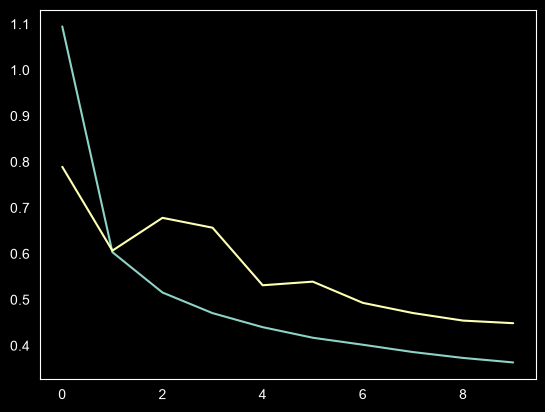

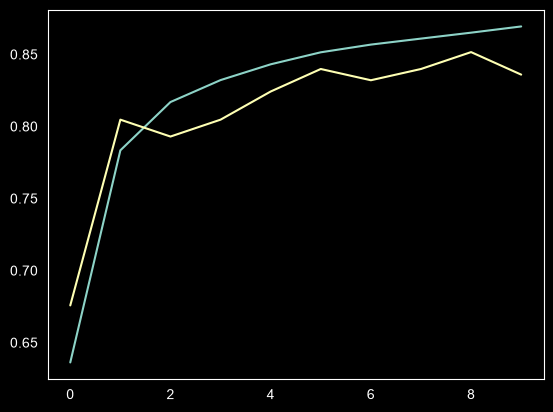

Validation Accuracy :  0.8359375
Validation Loss :  0.4487791061401367


In [15]:
a, l = train_this(optimizer, model)
val_accs.append(a)
val_losses.append(l)

### Momentum

In [16]:
model = get_model()

In [17]:
optimizer = torch.optim.SGD(model.parameters(),  momentum=0.9, lr=0.05)

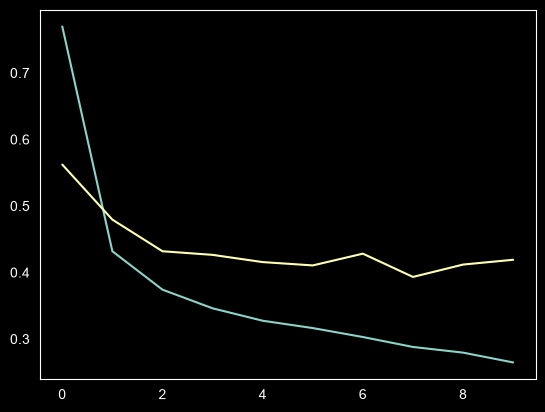

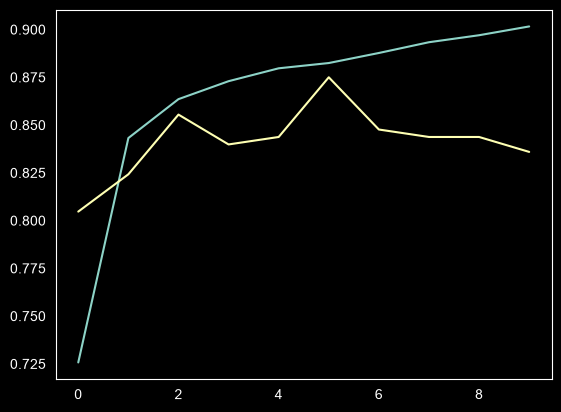

Validation Accuracy :  0.8359375
Validation Loss :  0.4190482199192047


In [18]:
a, l = train_this(optimizer, model)
val_accs.append(a)
val_losses.append(l)

### Nesterov Accelerated Gradient

In [19]:
model = get_model()

In [20]:
optimizer = torch.optim.SGD(model.parameters(),  momentum=0.9, lr=0.05)

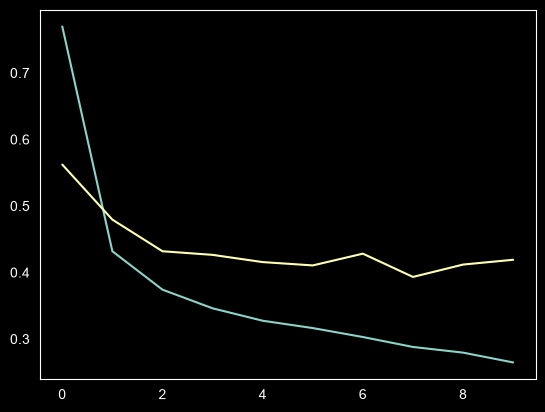

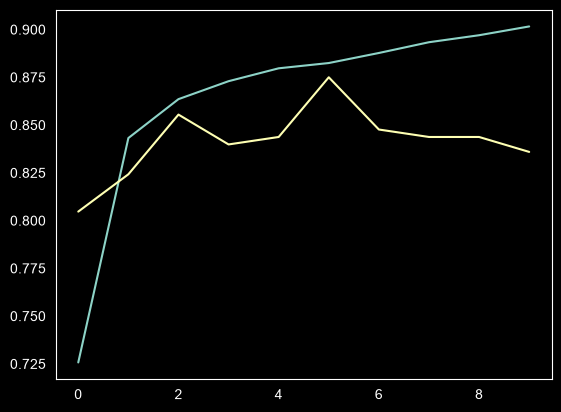

Validation Accuracy :  0.8359375
Validation Loss :  0.4190482199192047


In [21]:
a, l = train_this(optimizer, model)
val_accs.append(a)
val_losses.append(l)

### AdaGrad

In [22]:
model = get_model()

In [23]:
optimizer = torch.optim.Adagrad(model.parameters(), lr=0.05)

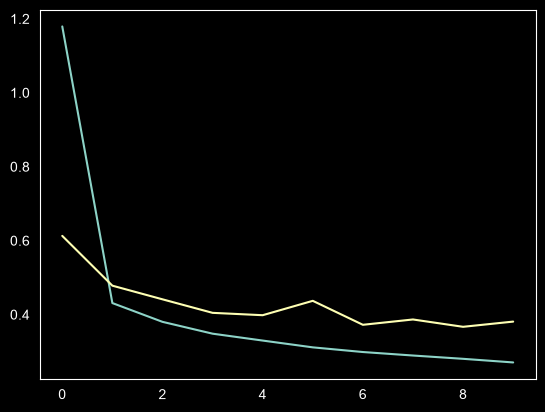

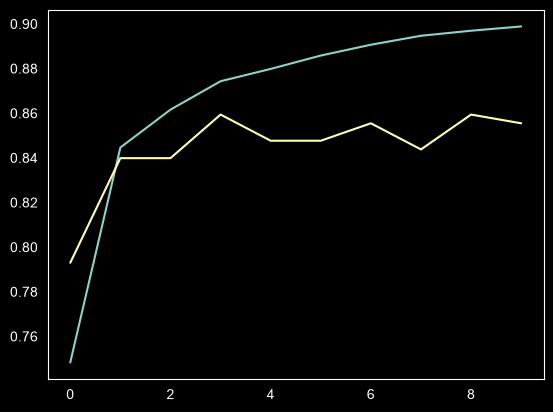

Validation Accuracy :  0.85546875
Validation Loss :  0.38095298409461975


In [24]:
a, l = train_this(optimizer, model)
val_accs.append(a)
val_losses.append(l)

### RMSProp

In [25]:
model = get_model()

In [26]:
optimizer = torch.optim.RMSprop(model.parameters(), alpha=0.9, lr=0.05)

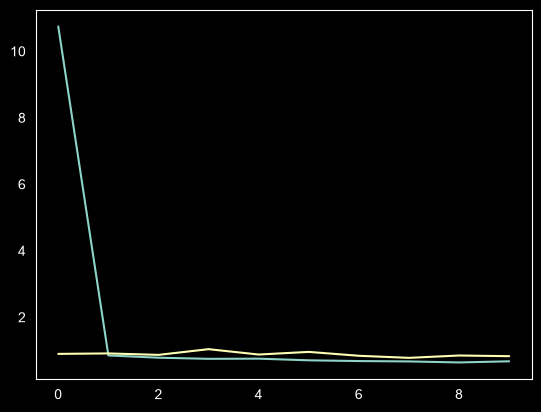

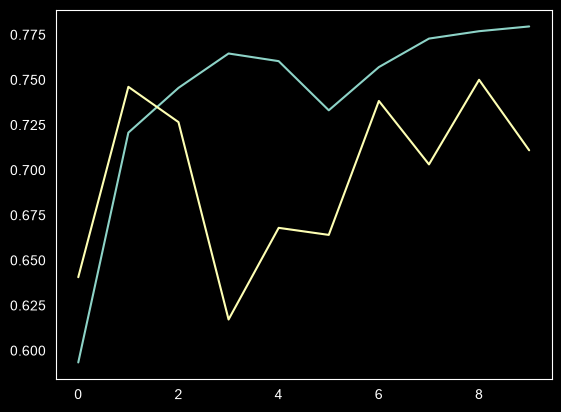

Validation Accuracy :  0.7109375
Validation Loss :  0.8247476816177368


In [27]:
a, l = train_this(optimizer, model)
val_accs.append(a)
val_losses.append(l)

### Adam

In [28]:
model = get_model()

In [29]:
optimizer = torch.optim.Adam(model.parameters(), betas=(0.9, 0.999), lr=0.05)

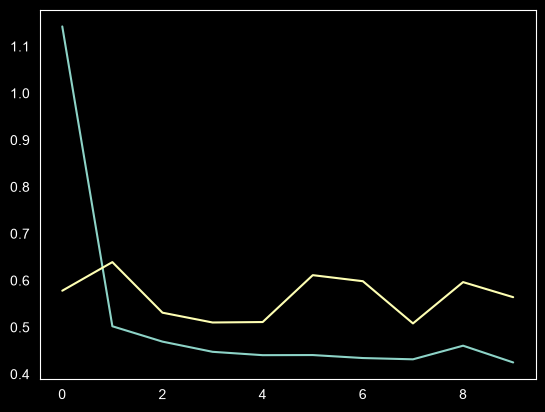

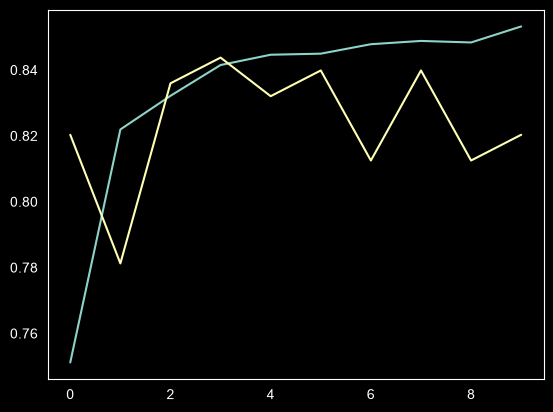

Validation Accuracy :  0.8203125
Validation Loss :  0.5642516613006592


In [30]:
a, l = train_this(optimizer, model)
val_accs.append(a)
val_losses.append(l)

### AdaMax

In [31]:
model = get_model()

In [32]:
optimizer = torch.optim.Adamax(model.parameters(), betas=(0.9, 0.999), lr=0.05)

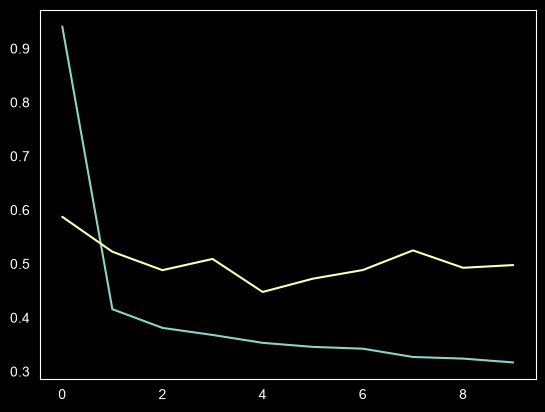

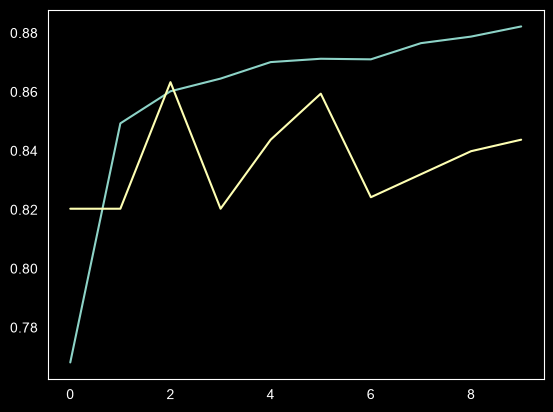

Validation Accuracy :  0.84375
Validation Loss :  0.4976852536201477


In [33]:
a, l = train_this(optimizer, model)
val_accs.append(a)
val_losses.append(l)

### AdamW

In [34]:
model = get_model()

In [35]:
optimizer = torch.optim.AdamW(model.parameters(), betas=(0.9, 0.999), lr=0.05)

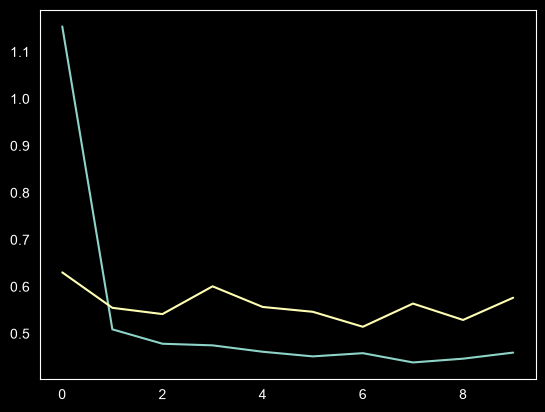

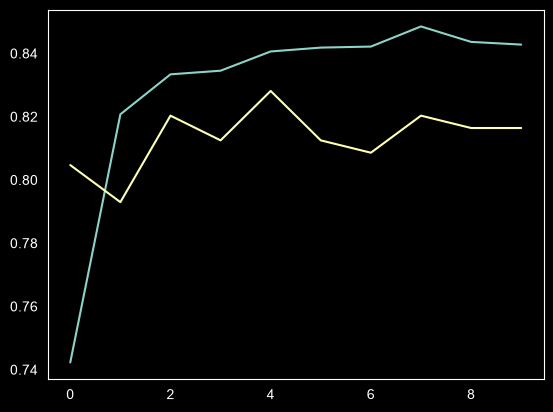

Validation Accuracy :  0.81640625
Validation Loss :  0.5764833688735962


In [36]:
a, l = train_this(optimizer, model)
val_accs.append(a)
val_losses.append(l)

### Comparision

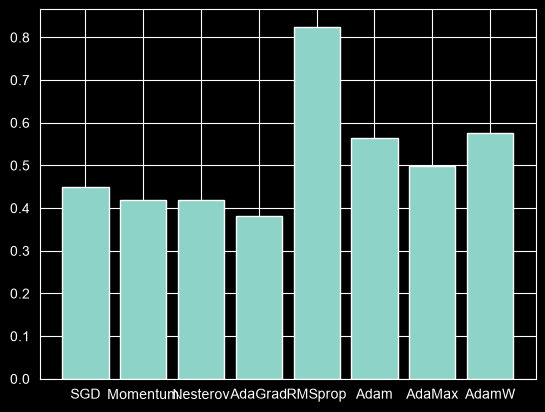

In [41]:
plt.bar(optimizers, val_losses,)
plt.show()

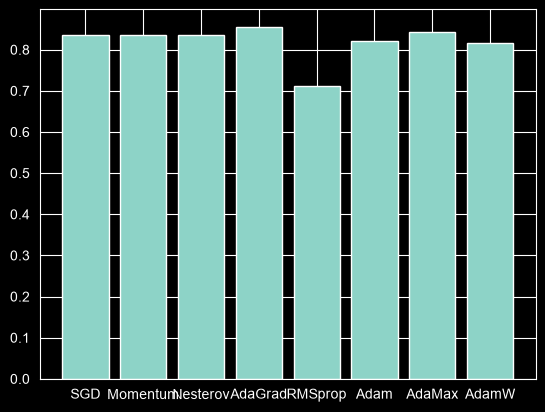

In [42]:
plt.bar(optimizers, val_accs)
plt.show()

end